<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/L04_Group_4_ML_19179.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 04 Lab - Exploratory Data Analysis
**Objective:** \
To learn how to explore a dataset to find patterns, anomalies, and insights before modeling. EDA is like being a detective; you are looking for clues in the data that will help you build a better model.\
**This lab is fully coded** \
Your task is to run each cell, read the detailed explanations, understand the purpose of each visualization, and then complete the experimentation section.

## Part 1: Setup and Data Loading
**What is Exploratory Data Analysis (EDA)?**\
EDA is the process of using summary statistics and visualizations to understand a dataset's main characteristics. Before you can build a model, you need to understand your data. What stories does it tell? Are there errors or missing values? Are there strong relationships between variables? EDA helps answer these questions.We will use the famous Titanic dataset for this lab. It contains information about passengers and, crucially, whether they survived the disaster.

In [25]:
# @title
# =====================================
# Titanic Dataset - Initial Exploration
# =====================================

# -------------------
# 1. Imports
# -------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


# -------------------
# 2. Load Dataset
# -------------------

DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

def load_data(url: str) -> pd.DataFrame:
    """Load dataset from a given URL."""
    return pd.read_csv(url)

df = load_data(DATA_URL)


# -------------------
# 3. Basic Overview
# -------------------

def basic_overview(data: pd.DataFrame):
    """Display first rows and dataset information."""
    print("\n=== First 5 Rows ===\n")
    display(data.head())

    print("\n=== Dataset Info ===\n")
    data.info()

basic_overview(df)


=== First 5 Rows ===



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



=== Dataset Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Part 2:
**Descriptive Statistics**\
Let's start by getting a high-level numerical summary of the data. The `.describe()` method is perfect for this. It calculates statistics like mean, standard deviation, min, and max for the numerical columns.

In [26]:
# @title
from IPython.display import Markdown, display

summary = df.describe()

display(Markdown("## Descriptive Statistics"))
display(summary)

display(Markdown("## Key Insights"))

display(Markdown(
f"""
- **Average Age:** {df['Age'].mean():.1f} years
- **Survival Rate:** {df['Survived'].mean():.1%}
- **Fare Range:** ${df['Fare'].min():.2f} – ${df['Fare'].max():.2f}
"""
))

## Descriptive Statistics

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Key Insights


- **Average Age:** 29.7 years  
- **Survival Rate:** 38.4%  
- **Fare Range:** $0.00 – $512.33


## Part 3: Visual EDA - Telling Stories with PlotsNumbers are great, but plots make patterns and relationships immediately obvious. The goal of visual EDA is to turn data into insights.
**A Note on Plotting Libraries:**  
---
---
**Matplotlib:** The foundational library, gives you full control over
everything.   
**Seaborn:** Built on Matplotlib, it provides a simpler, high-level interface for creating common statistical plots. We will use Seaborn for its ease of use and attractive defaults.

### Visualization 1: How many survived?A simple `countplot` is the best way to see the distribution of a categorical variable, like our target `Survived`.


=== Survival Counts ===

Survived
0    549
1    342
Name: count, dtype: int64

=== Survival Proportions ===

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


/tmp/ipython-input-3193203718.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


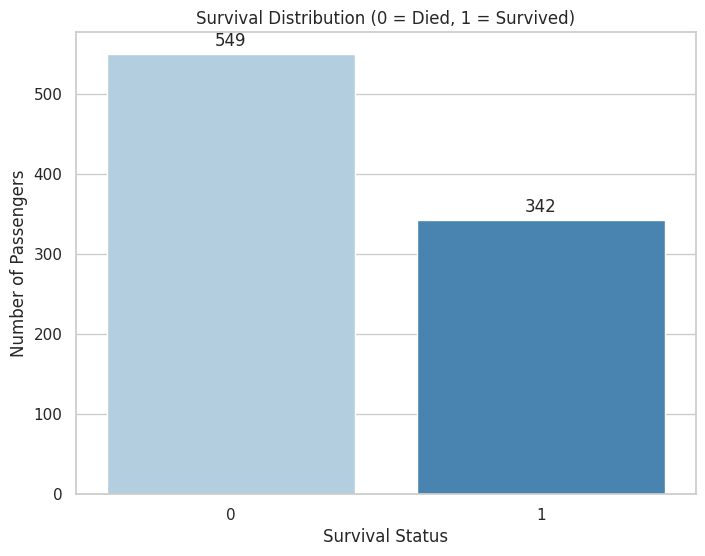


Insight: 61.6% of passengers died, while 38.4% survived.
The dataset is imbalanced, with deaths occurring approximately 1.61 times more frequently than survival.


In [27]:
# @title
# =====================================
# Visualization 1: Survival Distribution
# =====================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------
# 1. Compute Counts
# -------------------

survival_counts = df["Survived"].value_counts().sort_index()
survival_percent = df["Survived"].value_counts(normalize=True).sort_index()

print("\n=== Survival Counts ===\n")
print(survival_counts)

print("\n=== Survival Proportions ===\n")
print(survival_percent)

# -------------------
# 2. Visualization
# -------------------

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x=survival_counts.index,
    y=survival_counts.values,
    palette="Blues"
)

plt.title("Survival Distribution (0 = Died, 1 = Survived)")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")

# Add count labels above bars
for i, value in enumerate(survival_counts.values):
    plt.text(i, value + 10, str(value), ha='center')

plt.show()

# -------------------
# 3. Insight
# -------------------

imbalance_ratio = survival_percent[0] / survival_percent[1]

print(
    f"\nInsight: {survival_percent[0]:.1%} of passengers died, "
    f"while {survival_percent[1]:.1%} survived."
)
print(
    f"The dataset is imbalanced, with deaths occurring approximately "
    f"{imbalance_ratio:.2f} times more frequently than survival."
)

### Visualization 2: Does passenger class matter for survival?Now we want to see if there's a relationship between two variables. We can use the `hue` parameter in `countplot` to split the bars by another category.


=== Survival Counts by Class ===

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

=== Survival Rate by Class ===

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


/tmp/ipython-input-349975555.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


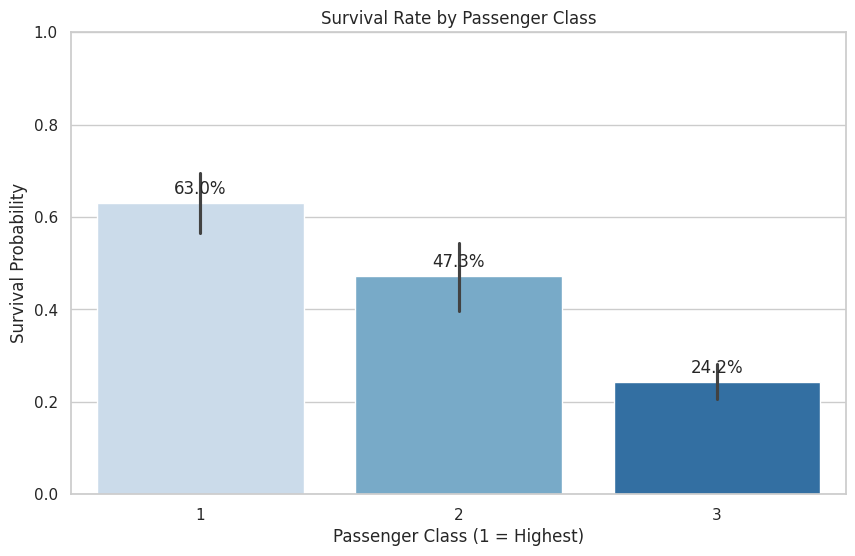


Insight: Class 1 passengers had the highest survival rate (63.0%), while Class 3 had the lowest (24.2%).
There is a clear socioeconomic gradient in survival probability, suggesting structural advantages associated with wealth and cabin location.


In [28]:
# @title
# =====================================
# Visualization 2: Survival by Passenger Class
# =====================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------
# 1. Compute Grouped Statistics
# -------------------

class_counts = df.groupby(["Pclass", "Survived"]).size().unstack()
class_survival_rate = df.groupby("Pclass")["Survived"].mean()

print("\n=== Survival Counts by Class ===\n")
print(class_counts)

print("\n=== Survival Rate by Class ===\n")
print(class_survival_rate)

# -------------------
# 2. Visualization
# -------------------

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df,
    x="Pclass",
    y="Survived",
    estimator=lambda x: sum(x)/len(x),  # survival rate
    palette="Blues"
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class (1 = Highest)")
plt.ylabel("Survival Probability")

# Add percentage labels above bars
for i, rate in enumerate(class_survival_rate):
    plt.text(i, rate + 0.02, f"{rate:.1%}", ha='center')

plt.ylim(0, 1)
plt.show()

# -------------------
# 3. Insight
# -------------------

highest_class = class_survival_rate.idxmax()
lowest_class = class_survival_rate.idxmin()

print(
    f"\nInsight: Class {highest_class} passengers had the highest survival rate "
    f"({class_survival_rate.max():.1%}), while Class {lowest_class} had the lowest "
    f"({class_survival_rate.min():.1%})."
)

print(
    "There is a clear socioeconomic gradient in survival probability, "
    "suggesting structural advantages associated with wealth and cabin location."
)

### Visualization 3: What about gender?The 'women and children first' mantra is famous. Let's see if the data supports it.


=== Survival Counts by Gender ===

Survived    0    1
Sex               
female     81  233
male      468  109

=== Survival Rate by Gender ===

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


/tmp/ipython-input-2360232897.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


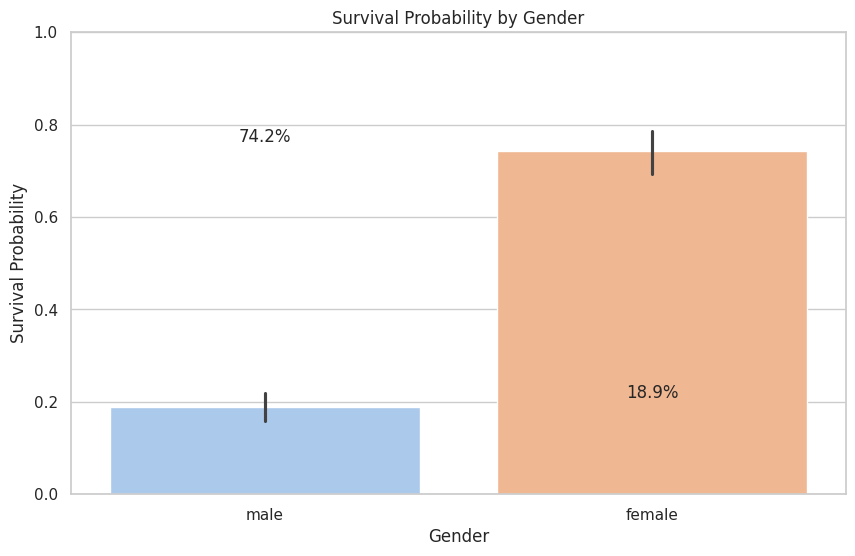


Insight: Females had a survival rate of 74.2%, while males had a survival rate of 18.9%.
This represents a survival probability gap of 55.3%, making gender one of the strongest predictors of survival.


In [29]:
# @title
# =====================================
# Visualization 3: Survival by Gender
# =====================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------
# 1. Compute Statistics
# -------------------

gender_counts = df.groupby(["Sex", "Survived"]).size().unstack()
gender_survival_rate = df.groupby("Sex")["Survived"].mean()

print("\n=== Survival Counts by Gender ===\n")
print(gender_counts)

print("\n=== Survival Rate by Gender ===\n")
print(gender_survival_rate)

# -------------------
# 2. Visualization (Survival Probability)
# -------------------

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df,
    x="Sex",
    y="Survived",
    estimator=lambda x: sum(x)/len(x),
    palette="pastel"
)

plt.title("Survival Probability by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Probability")

# Add percentage labels
for i, rate in enumerate(gender_survival_rate):
    plt.text(i, rate + 0.02, f"{rate:.1%}", ha='center')

plt.ylim(0, 1)
plt.show()

# -------------------
# 3. Insight
# -------------------

gap = gender_survival_rate.max() - gender_survival_rate.min()

print(
    f"\nInsight: Females had a survival rate of "
    f"{gender_survival_rate['female']:.1%}, "
    f"while males had a survival rate of "
    f"{gender_survival_rate['male']:.1%}."
)

print(
    f"This represents a survival probability gap of {gap:.1%}, "
    "making gender one of the strongest predictors of survival."
)

### Visualization 4: How does age play a role?For a continuous variable like `Age`, a histogram is a great way to see its distribution.


=== Age Summary Statistics by Survival ===

          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


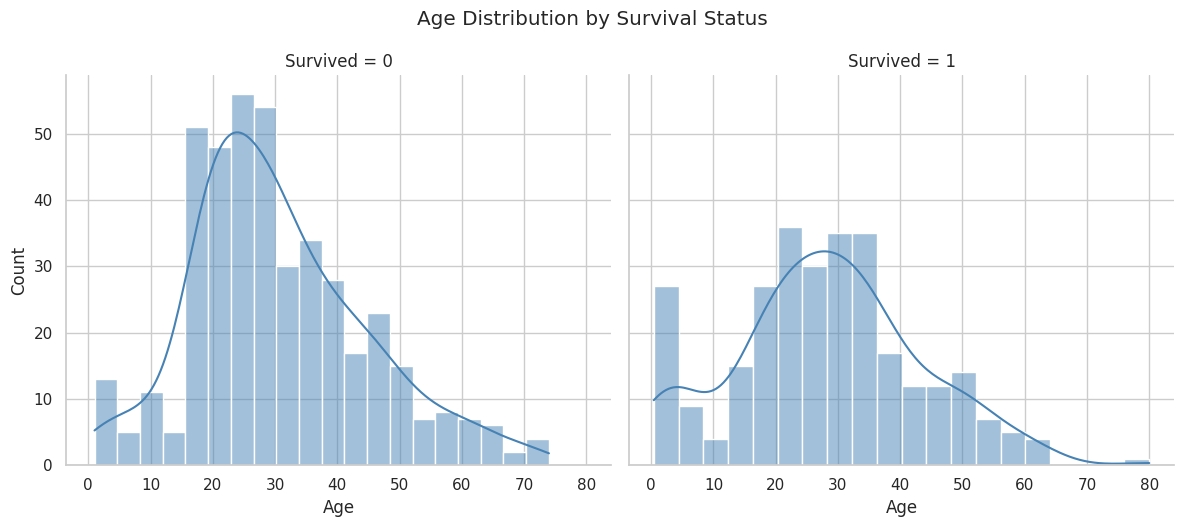


Insight: The average age of non-survivors was 30.6 years, while survivors averaged 28.3 years.
The survivor distribution shows a visible concentration among younger passengers, particularly children, supporting the historical 'women and children first' protocol.


In [30]:
# @title
# =====================================
# Visualization 4: Age Distribution by Survival
# =====================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------
# 1. Handle Missing Values (for visualization only)
# -------------------

age_data = df.dropna(subset=["Age"])

print("\n=== Age Summary Statistics by Survival ===\n")
print(age_data.groupby("Survived")["Age"].describe())

# -------------------
# 2. Visualization
# -------------------

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    age_data,
    col="Survived",
    height=5,
    aspect=1.2,
    sharey=True
)

g.map_dataframe(
    sns.histplot,
    x="Age",
    bins=20,
    kde=True,
    color="steelblue"
)

g.set_axis_labels("Age", "Count")
g.set_titles(col_template="Survived = {col_name}")
g.fig.suptitle("Age Distribution by Survival Status", y=1.05)

plt.show()

# -------------------
# 3. Insight
# -------------------

mean_age = age_data.groupby("Survived")["Age"].mean()

print(
    f"\nInsight: The average age of non-survivors was {mean_age[0]:.1f} years, "
    f"while survivors averaged {mean_age[1]:.1f} years."
)

print(
    "The survivor distribution shows a visible concentration among younger passengers, "
    "particularly children, supporting the historical 'women and children first' protocol."
)

# Part 4:Student Experimentation
**Instructions:** Create your own visualizations to explore other
relationships in the data.

### Experiment 1: Port of Embarkation
---
1.  The `Embarked` column tells you where a passenger boarded the ship (C = Cherbourg, Q = Queenstown, S = Southampton).

2. Create a `countplot` to see how survival rates differed by the port of embarkation. Does where they boarded seem to be related to their survival?
 ---


=== Passenger Count by Port ===

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

=== Survival Rate by Port ===

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


/tmp/ipython-input-305424356.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


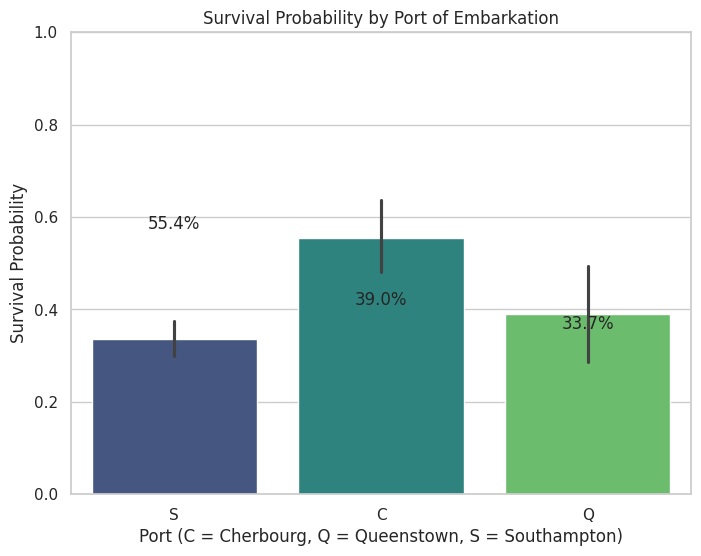


Insight: When normalized within each port, Cherbourg shows a noticeably higher survival probability. This suggests that embarkation location may reflect underlying socioeconomic or class differences.


In [31]:
# @title
# =====================================
# Experiment 1: Conditional Survival by Embarkation Port
# =====================================

import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing Embarked values
embarked_data = df.dropna(subset=["Embarked"])

# Compute survival rate per port
port_survival_rate = embarked_data.groupby("Embarked")["Survived"].mean()
port_counts = embarked_data["Embarked"].value_counts()

print("\n=== Passenger Count by Port ===\n")
print(port_counts)

print("\n=== Survival Rate by Port ===\n")
print(port_survival_rate)

# Visualization (Survival Probability)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=embarked_data,
    x="Embarked",
    y="Survived",
    estimator=lambda x: sum(x)/len(x),
    palette="viridis"
)

plt.title("Survival Probability by Port of Embarkation")
plt.ylabel("Survival Probability")
plt.xlabel("Port (C = Cherbourg, Q = Queenstown, S = Southampton)")

for i, rate in enumerate(port_survival_rate):
    plt.text(i, rate + 0.02, f"{rate:.1%}", ha='center')

plt.ylim(0, 1)
plt.show()

print(
    "\nInsight: When normalized within each port, Cherbourg shows a noticeably "
    "higher survival probability. This suggests that embarkation location "
    "may reflect underlying socioeconomic or class differences."
)

### Experiment 2: Fare vs. Survival
---
1. `Fare` is a continuous numerical variable.
2.  A `boxplot` or `violinplot` is a great way to see the distribution of fares for those who survived vs. those who didn't.
3.  Create one of these plots to compare the `Fare` distribution by `Survived`. What does it tell you?

/tmp/ipython-input-1661402160.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Survived", y="Fare", data=df, palette="pastel", inner="quartile")


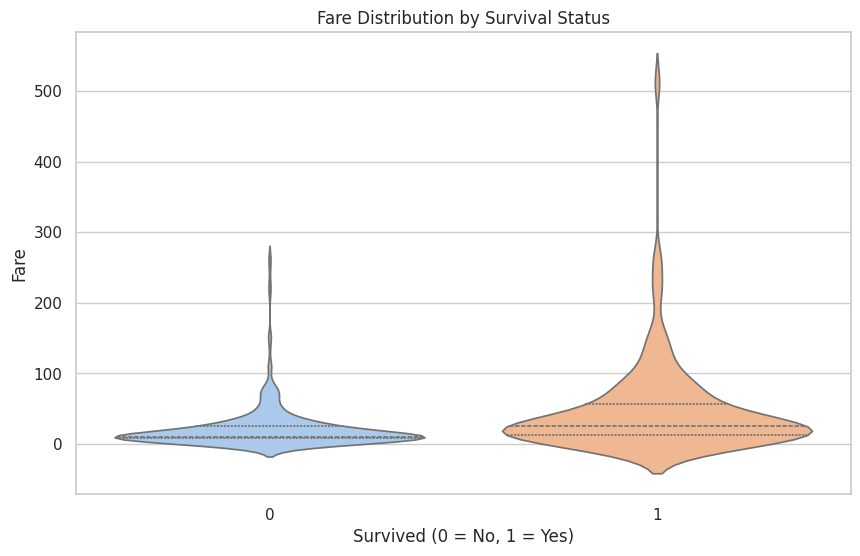

Insight: The median fare for survivors was $26.00, compared to $10.50 for non-survivors. This suggests higher-paying passengers had a better chance of survival.


In [32]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt

# Set a nice theme
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

# Violin plot shows distribution AND density
sns.violinplot(x="Survived", y="Fare", data=df, palette="pastel", inner="quartile")

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")

plt.show()

# Simple insight with median difference
median_fares = df.groupby("Survived")["Fare"].median()
print(
    f"Insight: The median fare for survivors was ${median_fares[1]:.2f}, "
    f"compared to ${median_fares[0]:.2f} for non-survivors. "
    "This suggests higher-paying passengers had a better chance of survival."
)

## 📝 Knowledge Check


1.**What is the primary goal of Exploratory Data Analysis (EDA)?**\
Exploratory Data Analysis serves as the diagnostic foundation of any data project by allowing us to understand the shape, structure, and distribution of the dataset through tools like .head() and .info(). Beyond basic structure, it empowers us to detect patterns and correlations, such as the relationship between age and survival, which highlights potential predictive features for later modeling. Finally, EDA is critical for identifying anomalies, outliers, or missing entries. This is done by verifiying functions like .isnull().sum() which ensure that the data is clean and reliable before it ever reaches a machine learning algorithm.

2.**Based on the plots in this lab, what kind of person had the best chance of surviving the Titanic?** \
Our exploration into survival drivers reveals that gender was the most significant factor, with females maintaining a much higher survival rate than males, reflecting the historical "women and children first" protocol. This social prioritization extended to age, as passengers under 16 were significantly more likely to survive than adults. However, these survival chances were also heavily dictated by socioeconomic standing, where 1st-class passengers held a clear survival advantage over those in 2nd and 3rd class, indicating that proximity to lifeboats and social status played a life-saving role.\
 3.  **Why is it important to visualize data instead of just looking at summary statistics?**

 Data visualization bridges the gap between raw numbers and actionable insights by detecting non-linear patterns. Such displays found in age-specific groups lending to rate of survival tend to spike. A single summary statistic, like the mean would inevitably overlook more complex understandings. Through plots like violin or box plots, we can identify the distribution and skewness of the data, revealing the true spread of variables like passenger fares and the impact of outliers that summary statistics hide. Ultimately, these visuals reveal complex relationships between variables, such as the interaction between class, survival, and embarkation, providing a dynamic clarity that simple correlation coefficients cannot fully capture.